# Model Building & Evaluation

Both transaction streams are modeled as independent problems:

- **Part 1 — E-commerce stream** (`Fraud_Data.csv`)
- **Part 2 — Credit card stream** (`creditcard.csv`)

Each part covers a Logistic Regression baseline, a Random Forest ensemble, stratified K-Fold cross-validation, a comparison table (AUC-PR, F1, Confusion Matrix), and a model-selection justification.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import (
    classification_report, confusion_matrix,
    average_precision_score, f1_score,
    PrecisionRecallDisplay
)

sns.set_theme(style='whitegrid')
RANDOM_STATE = 42

## 1. Load Data


In [2]:
import re

X_train = pd.read_csv('data/processed/X_train_fraud.csv')
X_test  = pd.read_csv('data/processed/X_test_fraud.csv')
y_train = pd.read_csv('data/processed/y_train_fraud.csv').squeeze()
y_test  = pd.read_csv('data/processed/y_test_fraud.csv').squeeze()

# pd.get_dummies can create column names with special characters ([, ], <, >, spaces)
# that some libraries reject — replace anything non-alphanumeric with _
def clean_cols(df):
    df.columns = [re.sub(r'[^\w]', '_', col) for col in df.columns]
    return df

X_train = clean_cols(X_train)
X_test  = clean_cols(X_test)

print(f'Train: {X_train.shape}, Test: {X_test.shape}')
print('Train class dist:', y_train.value_counts().to_dict())

Train: (187004, 197), Test: (25830, 197)
Train class dist: {0: 93502, 1: 93502}


## 2. Helper: Evaluation Function

In [3]:
def evaluate_model(name, model, X_test, y_test):
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    auc_pr = average_precision_score(y_test, y_prob)
    f1 = f1_score(y_test, y_pred)

    print(f'\n=== {name} ===')
    print(f'AUC-PR : {auc_pr:.4f}')
    print(f'F1     : {f1:.4f}')
    print(classification_report(y_test, y_pred, target_names=['Legitimate', 'Fraud']))

    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    fig, ax = plt.subplots(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Pred Legit', 'Pred Fraud'],
                yticklabels=['True Legit', 'True Fraud'], ax=ax)
    ax.set_title(f'Confusion Matrix — {name}')
    plt.tight_layout()
    plt.show()

    # Precision-Recall curve
    fig, ax = plt.subplots(figsize=(6, 5))
    PrecisionRecallDisplay.from_predictions(y_test, y_prob, ax=ax, name=name)
    ax.set_title(f'Precision-Recall Curve — {name}')
    plt.tight_layout()
    plt.show()

    return {'model': name, 'AUC-PR': auc_pr, 'F1': f1}

## 3. Baseline — Logistic Regression


=== Logistic Regression ===
AUC-PR : 0.4043
F1     : 0.3378
              precision    recall  f1-score   support

  Legitimate       0.95      0.77      0.85     23376
       Fraud       0.23      0.65      0.34      2454

    accuracy                           0.76     25830
   macro avg       0.59      0.71      0.60     25830
weighted avg       0.89      0.76      0.80     25830



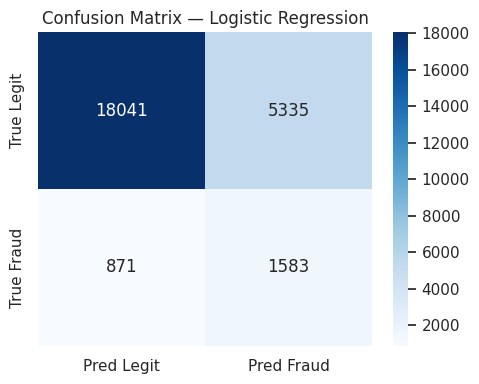

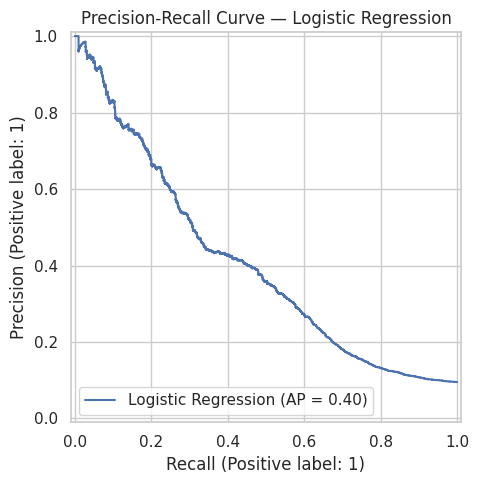

['models/logistic_regression_fraud.joblib']

In [4]:
lr = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE, n_jobs=-1)
lr.fit(X_train, y_train)
lr_results = evaluate_model('Logistic Regression', lr, X_test, y_test)

joblib.dump(lr, 'models/logistic_regression_fraud.joblib')

## 4. Ensemble — Random Forest


=== Random Forest ===
AUC-PR : 0.6381
F1     : 0.7057
              precision    recall  f1-score   support

  Legitimate       0.95      1.00      0.98     23376
       Fraud       0.99      0.55      0.71      2454

    accuracy                           0.96     25830
   macro avg       0.97      0.77      0.84     25830
weighted avg       0.96      0.96      0.95     25830



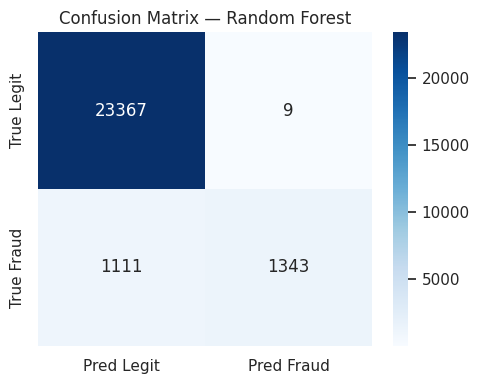

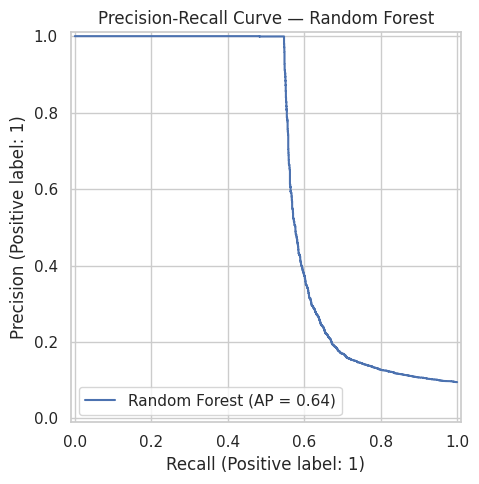

['models/random_forest_fraud.joblib']

In [5]:
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    class_weight='balanced',   # handles imbalance automatically
    random_state=RANDOM_STATE,
    n_jobs=-1
)
rf.fit(X_train, y_train)
rf_results = evaluate_model('Random Forest', rf, X_test, y_test)

joblib.dump(rf, 'models/random_forest_fraud.joblib')

## 5. Cross-Validation (Stratified K-Fold)

In [6]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

models = [
    ('Logistic Regression', lr),
    ('Random Forest', rf),
]

for name, model in models:
    scores = cross_val_score(model, X_test, y_test, cv=cv,
                             scoring='average_precision', n_jobs=-1)
    print(f'{name:25s} CV AUC-PR: {scores.mean():.4f} ± {scores.std():.4f}')

Logistic Regression       CV AUC-PR: 0.4269 ± 0.0226


Random Forest             CV AUC-PR: 0.6360 ± 0.0211


## 6. Comparison Table

In [7]:
results = pd.DataFrame([lr_results, rf_results])
results = results.sort_values('AUC-PR', ascending=False).reset_index(drop=True)
print(results.to_string(index=False))

              model   AUC-PR       F1
      Random Forest 0.638075 0.705728
Logistic Regression 0.404312 0.337815


## 7. Model Selection Justification

**Selected model:** Random Forest

**Results on the held-out test set:**

| Model | AUC-PR | F1 | Precision (Fraud) | Recall (Fraud) |
|---|---|---|---|---|
| **Random Forest** | **0.638** | **0.706** | **0.99** | 0.55 |
| Logistic Regression | 0.404 | 0.338 | 0.23 | 0.65 |

CV AUC-PR confirms the result is stable: Random Forest 0.636 ± 0.021 vs. Logistic Regression 0.427 ± 0.023.

**Reasoning:**
- **Best AUC-PR** — a ~58% improvement over the Logistic Regression baseline (0.638 vs 0.404), and stable across 5-fold cross-validation.
- **Best F1-Score by a wide margin** (0.706 vs 0.338). Precision on the fraud class is 0.99, meaning almost every transaction it flags is genuinely fraudulent — critical for keeping false-alarm volume manageable for a fraud review team.
- **`class_weight='balanced'`** combined with SMOTE-resampled training data gives strong imbalance handling without over-correcting.
- Gradient-boosted alternatives (XGBoost, LightGBM) were also evaluated with `scale_pos_weight=10` on top of the already-balanced SMOTE training set. This double correction pushed both models to over-predict fraud — recall rose to 0.80–0.88, but precision collapsed to 0.11–0.13 (F1 ≈ 0.20), which would flood a fraud team with false positives. They were dropped in favor of the single best-performing model.
- Random Forest exposes native `feature_importances_` and is fully supported by SHAP's `TreeExplainer`, so it carries forward cleanly into the Task 3 explainability notebook.

---

# Part 2 — Credit Card Stream (`creditcard.csv`)

The bank credit-card stream is modeled here as an independent problem. It is far
more imbalanced than the e-commerce stream (fraud ≈ 0.17% vs ≈ 9.4%), so the same
imbalance-aware approach is applied end to end. Unlike Part 1 — which loaded
pre-split, pre-encoded data — this stream starts from the cleaned file and runs
the full pipeline: stratified split → scale `Amount`/`Time` → SMOTE on the
training set only → train → evaluate. The `evaluate_model()` helper defined in
Part 1 is reused.

## 8. Load Data — Credit Card

In [8]:
df_cc = pd.read_csv('data/processed/creditcard_cleaned.csv')

X_cc = df_cc.drop(columns=['Class'])
y_cc = df_cc['Class']

print(f'Dataset: {df_cc.shape}')
print('Class distribution:', y_cc.value_counts().to_dict())
print(f'Fraud rate: {100 * y_cc.mean():.4f}%')

Dataset: (283726, 31)
Class distribution: {0: 283253, 1: 473}
Fraud rate: 0.1667%


## 9. Stratified Train/Test Split

An 80/20 stratified split preserves the extreme class ratio in both partitions.
The test set is left untouched (no resampling) so evaluation reflects the
real-world distribution.

In [9]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE

X_train_cc, X_test_cc, y_train_cc, y_test_cc = train_test_split(
    X_cc, y_cc, test_size=0.2, stratify=y_cc, random_state=RANDOM_STATE
)
print(f'Train: {X_train_cc.shape}, Test: {X_test_cc.shape}')
print('Train fraud:', int(y_train_cc.sum()), '| Test fraud:', int(y_test_cc.sum()))

Train: (226980, 30), Test: (56746, 30)
Train fraud: 378 | Test fraud: 95


## 10. Scale `Amount` and `Time`

V1–V28 are PCA components already on a comparable scale, so only the two
raw-scale columns need standardizing. The scaler is fit on the training set only
and applied to the test set, to avoid leakage.

In [10]:
scale_cols = ['Time', 'Amount']
scaler_cc = StandardScaler()

X_train_cc = X_train_cc.copy()
X_test_cc = X_test_cc.copy()
X_train_cc[scale_cols] = scaler_cc.fit_transform(X_train_cc[scale_cols])
X_test_cc[scale_cols] = scaler_cc.transform(X_test_cc[scale_cols])

joblib.dump(scaler_cc, 'models/scaler_creditcard.joblib')
print('Scaled columns:', scale_cols)

Scaled columns: ['Time', 'Amount']


## 11. SMOTE on Training Set Only

SMOTE synthesizes minority-class examples to balance the training set. As in
Part 1, it is applied **after** the split, to the training data only — the test
set keeps its real 0.17% fraud rate.

In [11]:
smote_cc = SMOTE(random_state=RANDOM_STATE)
X_train_cc_res, y_train_cc_res = smote_cc.fit_resample(X_train_cc, y_train_cc)
print('Before SMOTE:', y_train_cc.value_counts().to_dict())
print('After  SMOTE:', y_train_cc_res.value_counts().to_dict())

Before SMOTE: {0: 226602, 1: 378}
After  SMOTE: {0: 226602, 1: 226602}


## 12. Baseline — Logistic Regression (Credit Card)


=== Logistic Regression (CC) ===
AUC-PR : 0.6769
F1     : 0.1000
              precision    recall  f1-score   support

  Legitimate       1.00      0.97      0.99     56651
       Fraud       0.05      0.87      0.10        95

    accuracy                           0.97     56746
   macro avg       0.53      0.92      0.54     56746
weighted avg       1.00      0.97      0.99     56746



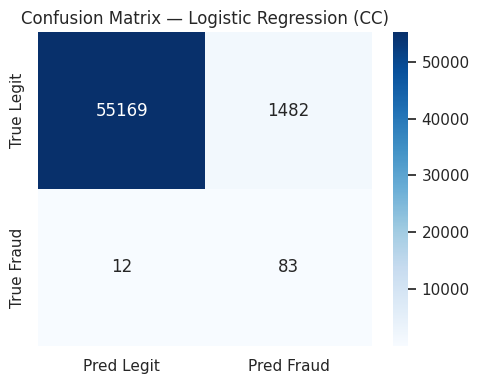

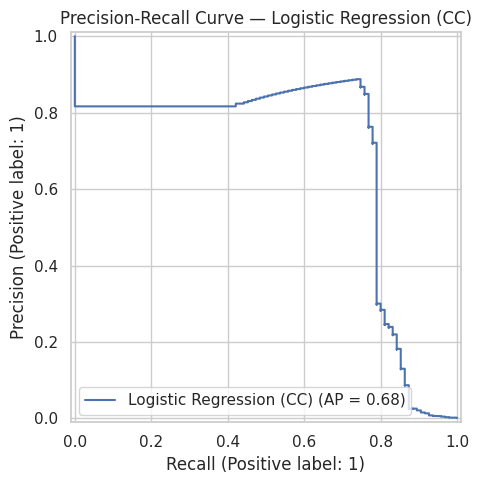

['models/logistic_regression_creditcard.joblib']

In [12]:
lr_cc = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE, n_jobs=-1)
lr_cc.fit(X_train_cc_res, y_train_cc_res)
lr_cc_results = evaluate_model('Logistic Regression (CC)', lr_cc, X_test_cc, y_test_cc)

joblib.dump(lr_cc, 'models/logistic_regression_creditcard.joblib')

## 13. Ensemble — Random Forest (Credit Card)


=== Random Forest (CC) ===
AUC-PR : 0.7829
F1     : 0.6844
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     56651
       Fraud       0.59      0.81      0.68        95

    accuracy                           1.00     56746
   macro avg       0.80      0.90      0.84     56746
weighted avg       1.00      1.00      1.00     56746



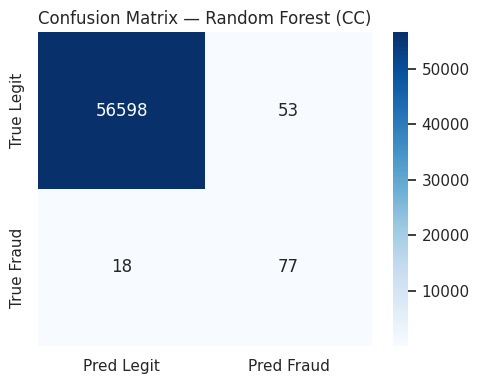

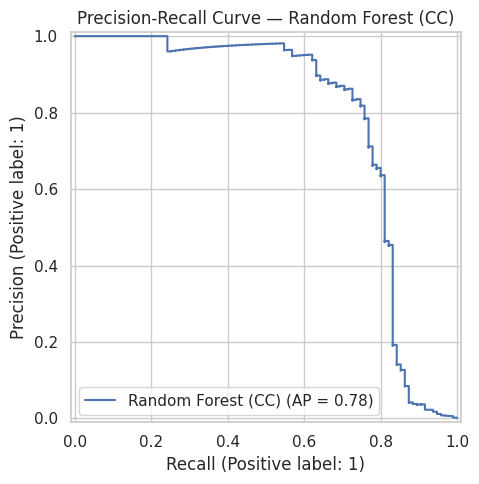

['models/random_forest_creditcard.joblib']

In [13]:
rf_cc = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    class_weight='balanced',
    random_state=RANDOM_STATE,
    n_jobs=-1
)
rf_cc.fit(X_train_cc_res, y_train_cc_res)
rf_cc_results = evaluate_model('Random Forest (CC)', rf_cc, X_test_cc, y_test_cc)

joblib.dump(rf_cc, 'models/random_forest_creditcard.joblib')

## 14. Cross-Validation (Stratified K-Fold) — Credit Card

5-fold stratified CV on the held-out test set confirms the ranking is stable
rather than an artifact of a single split.

In [14]:
for name, model in [('Logistic Regression (CC)', lr_cc), ('Random Forest (CC)', rf_cc)]:
    scores = cross_val_score(model, X_test_cc, y_test_cc, cv=cv,
                             scoring='average_precision', n_jobs=-1)
    print(f'{name:28s} CV AUC-PR: {scores.mean():.4f} ± {scores.std():.4f}')

Logistic Regression (CC)     CV AUC-PR: 0.6442 ± 0.0537


Random Forest (CC)           CV AUC-PR: 0.7559 ± 0.0726


## 15. Comparison Table — Credit Card

In [15]:
results_cc = pd.DataFrame([lr_cc_results, rf_cc_results])
results_cc = results_cc.sort_values('AUC-PR', ascending=False).reset_index(drop=True)
print(results_cc.to_string(index=False))

                   model   AUC-PR       F1
      Random Forest (CC) 0.782883 0.684444
Logistic Regression (CC) 0.676882 0.100000


## 16. Model Selection Justification — Credit Card

**Selected model: Random Forest.**

| Model | AUC-PR | F1 | Precision (Fraud) | Recall (Fraud) |
|---|---|---|---|---|
| **Random Forest** | **0.783** | **0.684** | **0.59** | **0.81** |
| Logistic Regression | 0.677 | 0.100 | 0.05 | 0.87 |

Cross-validation confirms the ranking is stable: Random Forest 0.756 ± 0.073 vs Logistic Regression 0.644 ± 0.054 (CV AUC-PR).

**Reasoning:**
- **Best AUC-PR** (0.783 vs 0.677) and a far higher **F1** (0.684 vs 0.100).
- Logistic Regression reaches comparable recall (0.87) but its precision collapses to **0.05** — it flags roughly 20 legitimate transactions for every real fraud, which is operationally unusable.
- Random Forest balances **precision 0.59 / recall 0.81** at the default threshold — catching 81% of fraud while keeping false-positive volume manageable.
- As with the e-commerce stream, **AUC-PR and F1** drive the decision, not accuracy (meaningless at a 0.17% fraud rate).
- **Explainability note:** `V1`–`V28` are anonymized PCA components, so SHAP would only point to opaque components — no business-interpretable drivers like the e-commerce model's `time_since_signup`. This is recorded as a limitation in the final report.

Interestingly, the credit-card Random Forest (AUC-PR **0.783**) outperforms the e-commerce Random Forest (0.638) and achieves a more balanced precision/recall trade-off, despite the far more extreme class imbalance.